# DATA266 Lab 1 Part 1 - Anushka

This notebook prepares and trains your character-level GPT-style language model from scratch.


# Task 1 Build a GPT Style LLM From Scratch

**Role:** AI Research Engineer, Language Modeling Team

This notebook follows the Task 1 requirements from the lab PDF. It uses TinyStories, character-level tokenization, manually implemented causal self-attention, and autoregressive generation.

No prebuilt Transformer or attention modules are used.


In [1]:
!pip -q install datasets tqdm matplotlib

## 1.1 Data Preprocessing

This section:
- Loads TinyStories.
- Tokenizes text at the character level.
- Creates char_to_idx and idx_to_char dictionaries.
- Creates fixed-length input-target sequences.
- Creates the member-specific 100,000-sequence training split and 10,000-sequence validation split.


In [2]:
from pathlib import Path
import json, os, time, math, random

# Repo-relative paths (no personal paths). This notebook lives in
# task1_llm/member_anushka/src/, so walk up until the repo root is found.
REPO_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'task1_llm').is_dir())
MEMBER_NAME = 'anushka'
MEMBER_DIR = REPO_ROOT / 'task1_llm' / f'member_{MEMBER_NAME}'

DATA_DIR = REPO_ROOT / 'task1_llm' / 'data'          # shared raw data (gitignored)
PROCESSED_DIR = MEMBER_DIR / 'data_processed'         # my own vocab / processed files
CHECKPOINT_DIR = MEMBER_DIR / 'checkpoints'
OUTPUT_DIR = MEMBER_DIR / 'outputs'
CONFIG_DIR = MEMBER_DIR / 'src'
LOG_DIR = REPO_ROOT / 'reproducibility' / 'raw_logs' / f'task1_llm_{MEMBER_NAME}'
MANIFEST_DIR = REPO_ROOT / 'reproducibility' / 'manifests'

for folder in [DATA_DIR, PROCESSED_DIR, CHECKPOINT_DIR, OUTPUT_DIR, CONFIG_DIR, LOG_DIR, MANIFEST_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

RUN_ID = time.strftime('%Y%m%d_%H%M%S')
print('Repo root:', REPO_ROOT)
print('Member folder:', MEMBER_DIR)
print('Run ID:', RUN_ID)

Repo root: /app
Member folder: /app/task1_llm/member_anushka
Run ID: 20260929_225852


In [3]:
CONFIG = {
    'member': 'Anushka',
    'seed': 3963,
    'sequence_length': 512,
    'train_sequences': 100_000,
    'validation_sequences': 10_000,
    'n_blocks': 6,
    'n_heads': 6,
    'd_model': 384,
    'd_ff': 1536,
    'dropout': 0.15,
    'batch_size': 128,
    'epochs': 20,
    'min_epochs_required': 10,
    'learning_rate': 6e-4,
    'weight_decay': 0.1,
    'warmup_steps': 800,
    'min_learning_rate': 3e-5,
    'gradient_clip_norm': 1.0,
    'use_bf16_autocast': True,
    'temperature': 0.8,
    'max_generation_tokens': 300,
    'log_every_steps': 50,
}

# Full training run by default. Set env var TASK1_SMOKE=1 for a short smoke test
# (1 epoch x 20 batches) — used by the README one-command reproduction.
RUN_FULL_TRAINING = os.environ.get('TASK1_SMOKE', '0') != '1'
SMOKE_MAX_BATCHES = 20
SMOKE_EVAL_BATCHES = 10

CONFIG_DIR.joinpath('config.json').write_text(json.dumps(CONFIG, indent=2))
print('RUN_FULL_TRAINING =', RUN_FULL_TRAINING)
print(json.dumps(CONFIG, indent=2))

RUN_FULL_TRAINING = True
{
  "member": "Anushka",
  "seed": 3963,
  "sequence_length": 512,
  "train_sequences": 100000,
  "validation_sequences": 10000,
  "n_blocks": 6,
  "n_heads": 6,
  "d_model": 384,
  "d_ff": 1536,
  "dropout": 0.15,
  "batch_size": 128,
  "epochs": 20,
  "min_epochs_required": 10,
  "learning_rate": 0.0006,
  "weight_decay": 0.1,
  "warmup_steps": 800,
  "min_learning_rate": 3e-05,
  "gradient_clip_norm": 1.0,
  "use_bf16_autocast": true,
  "temperature": 0.8,
  "max_generation_tokens": 300,
  "log_every_steps": 50
}


In [4]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from datasets import load_dataset
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

SEED = CONFIG['seed']
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('PyTorch:', torch.__version__, '| CUDA build:', torch.version.cuda)
print('Device:', device)
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
    # Fails fast if this PyTorch build has no kernels for the GPU (e.g. RTX 50xx needs CUDA 12.8+ builds)
    _ = (torch.ones(2, 2, device=device) @ torch.ones(2, 2, device=device)).sum().item()
    print('GPU kernel check: OK')

# bf16 mixed precision: matmuls run in bf16, softmax / loss stay in fp32. bf16 has the
# same exponent range as fp32, so no loss scaling is needed (unlike fp16).
USE_AMP = CONFIG['use_bf16_autocast'] and torch.cuda.is_available() and torch.cuda.is_bf16_supported()
def autocast():
    return torch.autocast(device_type='cuda', dtype=torch.bfloat16, enabled=USE_AMP)
print('bf16 autocast:', USE_AMP)

/opt/conda/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch: 2.8.0+cu128 | CUDA build: 12.8
Device: cuda
GPU: NVIDIA GeForce RTX 5090
GPU kernel check: OK
bf16 autocast: True


In [5]:
RAW_CORPUS_FILE = DATA_DIR / f'tinystories_corpus_seed{SEED}.txt'
needed_chars = (CONFIG['train_sequences'] + CONFIG['validation_sequences']) * (CONFIG['sequence_length'] + 1)

if RAW_CORPUS_FILE.exists() and RAW_CORPUS_FILE.stat().st_size >= needed_chars:
    corpus = RAW_CORPUS_FILE.read_text(encoding='utf-8')
    print('Loaded saved corpus:', len(corpus), 'characters')
else:
    print('Streaming TinyStories until enough characters are collected...')
    stream = load_dataset(
        'roneneldan/TinyStories',
        split='train',
        streaming=True
    ).shuffle(seed=SEED, buffer_size=10_000)

    pieces = []
    total_chars = 0
    for row in tqdm(stream, desc='Reading stories'):
        text = row['text'].strip()
        if text:
            pieces.append(text)
            total_chars += len(text) + 2
        if total_chars >= needed_chars:
            break

    corpus = '\n\n'.join(pieces)
    RAW_CORPUS_FILE.write_text(corpus, encoding='utf-8')
    print('Saved corpus:', RAW_CORPUS_FILE)
    print('Characters:', len(corpus))

if len(corpus) < needed_chars:
    raise RuntimeError(f'Corpus is too short: {len(corpus)} < {needed_chars}')

Loaded saved corpus: 56430721 characters


In [6]:
chars = sorted(set(corpus))
char_to_idx = {ch: i for i, ch in enumerate(chars)}
idx_to_char = {i: ch for ch, i in char_to_idx.items()}
encoded = np.array([char_to_idx[ch] for ch in corpus], dtype=np.int64)

vocab_path = PROCESSED_DIR / 'character_vocabulary.json'
vocab_path.write_text(json.dumps({
    'chars': chars,
    'char_to_idx': char_to_idx
}, ensure_ascii=False, indent=2), encoding='utf-8')

print('Vocabulary size:', len(chars))
print('First characters:', repr(corpus[:200]))

Vocabulary size: 107
First characters: 'Lily and Ben were twins who liked to play with their toys. They had many toys, but they always wanted more. They asked their mom and dad for new toys every day. Mom and dad said no, because they had e'


In [7]:
SEQ_LEN = CONFIG['sequence_length']
TOTAL_SEQUENCES = CONFIG['train_sequences'] + CONFIG['validation_sequences']
required = TOTAL_SEQUENCES * (SEQ_LEN + 1)

usable = encoded[:required]
windows = usable.reshape(TOTAL_SEQUENCES, SEQ_LEN + 1)

X = windows[:, :-1]
Y = windows[:, 1:]

train_X = torch.tensor(X[:CONFIG['train_sequences']], dtype=torch.long)
train_Y = torch.tensor(Y[:CONFIG['train_sequences']], dtype=torch.long)
val_X = torch.tensor(X[CONFIG['train_sequences']:], dtype=torch.long)
val_Y = torch.tensor(Y[CONFIG['train_sequences']:], dtype=torch.long)

print('Train input shape:', train_X.shape)
print('Validation input shape:', val_X.shape)
print('One input example:', ''.join(idx_to_char[int(i)] for i in train_X[0][:100]))


Train input shape: torch.Size([100000, 512])
Validation input shape: torch.Size([10000, 512])
One input example: Lily and Ben were twins who liked to play with their toys. They had many toys, but they always wante


In [8]:
class CharacterSequenceDataset(Dataset):
    def __init__(self, inputs, targets):
        self.inputs = inputs
        self.targets = targets

    def __len__(self):
        return len(self.inputs)

    def __getitem__(self, index):
        return self.inputs[index], self.targets[index]

train_dataset = CharacterSequenceDataset(train_X, train_Y)
val_dataset = CharacterSequenceDataset(val_X, val_Y)

# num_workers=0: data is already in memory, and Docker's small default /dev/shm
# can crash multi-worker DataLoaders ("bus error").
train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=True,
    pin_memory=torch.cuda.is_available(),
    num_workers=0
)
val_loader = DataLoader(
    val_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=False,
    pin_memory=torch.cuda.is_available(),
    num_workers=0
)

print('Training batches:', len(train_loader))
print('Validation batches:', len(val_loader))

Training batches: 782
Validation batches: 79


## 1.2 GPT Model Implementation

This section implements the model from scratch:
- Token and positional embeddings.
- Multi-head self-attention.
- Causal masking.
- Layer normalization.
- Feed-forward network.
- Residual connections.
- Language-modeling head.


In [9]:
class ManualCausalSelfAttention(nn.Module):
    def __init__(self, d_model, n_heads, dropout):
        super().__init__()
        if d_model % n_heads != 0:
            raise ValueError('d_model must be divisible by n_heads')
        self.n_heads = n_heads
        self.head_dim = d_model // n_heads
        self.qkv = nn.Linear(d_model, 3 * d_model)
        self.out_proj = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        batch_size, seq_len, d_model = x.shape
        qkv = self.qkv(x)
        qkv = qkv.view(batch_size, seq_len, 3, self.n_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]

        scores = (q @ k.transpose(-2, -1)) / math.sqrt(self.head_dim)
        causal_mask = torch.triu(
            torch.ones(seq_len, seq_len, device=x.device, dtype=torch.bool),
            diagonal=1
        )
        scores = scores.masked_fill(causal_mask, float('-inf'))
        weights = torch.softmax(scores, dim=-1)
        weights = self.dropout(weights)

        attended = weights @ v
        attended = attended.transpose(1, 2).contiguous()
        attended = attended.view(batch_size, seq_len, d_model)
        return self.out_proj(attended)

class TransformerBlock(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model)
        self.attention = ManualCausalSelfAttention(d_model, n_heads, dropout)
        self.ln2 = nn.LayerNorm(d_model)
        self.feed_forward = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.GELU(),
            nn.Linear(d_ff, d_model),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        x = x + self.attention(self.ln1(x))
        x = x + self.feed_forward(self.ln2(x))
        return x

class GPTFromScratch(nn.Module):
    def __init__(self, vocab_size, config):
        super().__init__()
        d_model = config['d_model']
        self.token_embedding = nn.Embedding(vocab_size, d_model)
        self.position_embedding = nn.Embedding(config['sequence_length'], d_model)
        self.blocks = nn.ModuleList([
            TransformerBlock(
                d_model=d_model,
                n_heads=config['n_heads'],
                d_ff=config['d_ff'],
                dropout=config['dropout']
            )
            for _ in range(config['n_blocks'])
        ])
        self.final_ln = nn.LayerNorm(d_model)
        self.language_model_head = nn.Linear(d_model, vocab_size)

    def forward(self, token_ids):
        batch_size, seq_len = token_ids.shape
        positions = torch.arange(seq_len, device=token_ids.device)
        x = self.token_embedding(token_ids) + self.position_embedding(positions)[None, :, :]
        for block in self.blocks:
            x = block(x)
        x = self.final_ln(x)
        return self.language_model_head(x)

model = GPTFromScratch(len(chars), CONFIG).to(device)
parameter_count = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable parameters: {parameter_count:,}')


Trainable parameters: 10,926,443


In [10]:
sample_x, sample_y = next(iter(train_loader))
sample_x = sample_x[:2].to(device)
sample_y = sample_y[:2].to(device)
with torch.no_grad():
    sample_logits = model(sample_x)
loss = nn.functional.cross_entropy(
    sample_logits.reshape(-1, len(chars)),
    sample_y.reshape(-1)
)
print('Logits shape:', sample_logits.shape)
print('Smoke-test loss:', float(loss))


Logits shape: torch.Size([2, 512, 107])
Smoke-test loss: 4.778684616088867


## 1.3 Training and Text Generation

This section trains with cross-entropy loss, learning-rate warm-up, cosine scheduling, gradient clipping, validation loss tracking, checkpoint saving, and autoregressive text generation.


In [11]:
def build_scheduler(optimizer, total_steps):
    warmup = CONFIG['warmup_steps']
    min_lr_ratio = CONFIG['min_learning_rate'] / CONFIG['learning_rate']

    def lr_lambda(step):
        if step < warmup:
            return max(1e-8, (step + 1) / max(1, warmup))
        progress = (step - warmup) / max(1, total_steps - warmup)
        cosine = 0.5 * (1.0 + math.cos(math.pi * min(1.0, progress)))
        return min_lr_ratio + (1.0 - min_lr_ratio) * cosine

    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

def build_optimizer(model):
    # Weight decay only on 2-D weight matrices (Linear layers). Biases, LayerNorm gains
    # and embedding tables are left undecayed, so decay regularises the projections
    # without shrinking normalisation scales or token/position vectors toward zero.
    decay, no_decay = [], []
    for name, param in model.named_parameters():
        if not param.requires_grad:
            continue
        if param.dim() >= 2 and 'embedding' not in name:
            decay.append(param)
        else:
            no_decay.append(param)
    return torch.optim.AdamW(
        [{'params': decay, 'weight_decay': CONFIG['weight_decay']},
         {'params': no_decay, 'weight_decay': 0.0}],
        lr=CONFIG['learning_rate'], betas=(0.9, 0.95)
    )

def evaluate(model, loader, max_batches=None):
    model.eval()
    total_loss, total_tokens = 0.0, 0
    with torch.no_grad():
        for batch_index, (x, y) in enumerate(loader):
            if max_batches is not None and batch_index >= max_batches:
                break
            x, y = x.to(device), y.to(device)
            with autocast():
                logits = model(x)
            loss = nn.functional.cross_entropy(
                logits.float().reshape(-1, len(chars)), y.reshape(-1), reduction='sum'
            )
            total_loss += float(loss)
            total_tokens += y.numel()
    return total_loss / max(1, total_tokens)

def save_checkpoint(path, model, history, epoch, val_loss):
    torch.save({
        'model_state_dict': model.state_dict(),
        'config': CONFIG,
        'char_to_idx': char_to_idx,
        'idx_to_char': idx_to_char,
        'history': history,
        'epoch': epoch,
        'val_loss': val_loss,
        'run_id': RUN_ID,
    }, path)

def train_model(model):
    full_run = RUN_FULL_TRAINING
    epochs = CONFIG['epochs'] if full_run else 1
    max_train_batches = None if full_run else SMOKE_MAX_BATCHES
    max_eval_batches = None if full_run else SMOKE_EVAL_BATCHES

    steps_per_epoch = len(train_loader) if max_train_batches is None else min(len(train_loader), max_train_batches)
    total_steps = epochs * steps_per_epoch
    optimizer = build_optimizer(model)
    scheduler = build_scheduler(optimizer, total_steps)

    history = {'train_loss': [], 'val_loss': [], 'gradient_norm': [], 'max_gradient_norm': [],
               'learning_rate': [], 'tokens_per_sec': [], 'tokens_seen': [],
               'step': [], 'step_loss': [], 'step_grad_norm': []}
    run_type = 'full' if full_run else 'smoke'
    log_path = LOG_DIR / f'{run_type}_training_log_{RUN_ID}.txt'   # new file per run; never edit afterwards

    run_start = time.time()
    nan_count = 0
    global_step = 0
    best_val = float('inf')
    best_epoch = None

    with log_path.open('w') as log:
        log.write(f'run_id={RUN_ID} run_type={run_type} config={json.dumps(CONFIG)}\n')
        log.write(f'device={device} gpu={torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"} torch={torch.__version__} bf16_autocast={USE_AMP}\n')
        for epoch in range(epochs):
            model.train()
            total_loss, total_tokens, grad_values = 0.0, 0, []
            start_time = time.time()
            progress = tqdm(train_loader, total=steps_per_epoch, desc=f'Epoch {epoch+1}/{epochs}', mininterval=30)

            for batch_index, (x, y) in enumerate(progress):
                if max_train_batches is not None and batch_index >= max_train_batches:
                    break
                x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
                optimizer.zero_grad(set_to_none=True)
                with autocast():
                    logits = model(x)
                loss = nn.functional.cross_entropy(
                    logits.float().reshape(-1, len(chars)), y.reshape(-1)
                )
                if not torch.isfinite(loss):
                    nan_count += 1
                    log.write(f'step={global_step} NON_FINITE_LOSS\n')
                    continue
                loss.backward()
                grad_norm = torch.nn.utils.clip_grad_norm_(
                    model.parameters(), CONFIG['gradient_clip_norm']
                )
                optimizer.step()
                scheduler.step()
                global_step += 1

                loss_value = float(loss.detach())
                grad_value = float(grad_norm)
                total_loss += loss_value * y.numel()
                total_tokens += y.numel()
                grad_values.append(grad_value)
                progress.set_postfix(loss=f'{loss_value:.4f}')

                if global_step % CONFIG['log_every_steps'] == 0:
                    lr_now = optimizer.param_groups[0]['lr']
                    history['step'].append(global_step)
                    history['step_loss'].append(loss_value)
                    history['step_grad_norm'].append(grad_value)
                    log.write(f'step={global_step} loss={loss_value:.6f} grad_norm={grad_value:.6f} lr={lr_now:.8f}\n')

            train_loss = total_loss / max(1, total_tokens)
            val_loss = evaluate(model, val_loader, max_eval_batches)
            elapsed = time.time() - start_time
            history['train_loss'].append(train_loss)
            history['val_loss'].append(val_loss)
            history['gradient_norm'].append(float(np.mean(grad_values)))
            history['max_gradient_norm'].append(float(np.max(grad_values)))
            history['learning_rate'].append(optimizer.param_groups[0]['lr'])
            history['tokens_seen'].append(total_tokens)
            history['tokens_per_sec'].append(total_tokens / max(elapsed, 1e-9))

            line = (
                f'Epoch {epoch+1}: train_loss={train_loss:.6f}, '
                f'val_loss={val_loss:.6f}, gradient_norm_mean={history["gradient_norm"][-1]:.6f}, '
                f'gradient_norm_max={history["max_gradient_norm"][-1]:.6f}, '
                f'tokens_per_sec={history["tokens_per_sec"][-1]:.1f}, time_seconds={elapsed:.2f}\n'
            )
            print(line.strip())
            log.write(line)
            log.flush()

            prefix = '' if full_run else 'smoke_'
            save_checkpoint(CHECKPOINT_DIR / f'{prefix}last_model.pt', model, history, epoch + 1, val_loss)
            if val_loss < best_val:
                best_val, best_epoch = val_loss, epoch + 1
                save_checkpoint(CHECKPOINT_DIR / f'{prefix}best_model.pt', model, history, epoch + 1, val_loss)
                log.write(f'Saved best checkpoint at epoch {epoch+1} (val_loss={val_loss:.6f})\n')

        history['nan_count'] = nan_count
        history['total_training_time_seconds'] = time.time() - run_start
        history['best_epoch'] = best_epoch
        history['best_val_loss'] = best_val
        log.write(f'DONE nan_count={nan_count} total_training_time_seconds={history["total_training_time_seconds"]:.2f} '
                  f'best_epoch={best_epoch} best_val_loss={best_val:.6f}\n')

    (OUTPUT_DIR / f'history_{RUN_ID}.json').write_text(json.dumps(history, indent=2))
    return history

if torch.cuda.is_available():
    torch.cuda.reset_peak_memory_stats()
history = train_model(model)
print('Training complete.')

Epoch 1/20: 100%|██████████| 782/782 [02:05<00:00,  6.25it/s, loss=1.5274]


Epoch 1: train_loss=2.244564, val_loss=1.443228, gradient_norm_mean=0.527086, gradient_norm_max=2.263467, tokens_per_sec=396015.4, time_seconds=129.29


Epoch 2/20: 100%|██████████| 782/782 [02:02<00:00,  6.38it/s, loss=0.9739]


Epoch 2: train_loss=1.158075, val_loss=0.921911, gradient_norm_mean=0.362890, gradient_norm_max=0.777569, tokens_per_sec=403871.8, time_seconds=126.77


Epoch 3/20: 100%|██████████| 782/782 [02:02<00:00,  6.38it/s, loss=0.8087]


...

Epoch 18: train_loss=0.566743, val_loss=0.566948, gradient_norm_mean=0.166727, gradient_norm_max=0.327785, tokens_per_sec=400333.1, time_seconds=127.89


Epoch 19/20: 100%|██████████| 782/782 [02:03<00:00,  6.31it/s, loss=0.5533]


Epoch 19: train_loss=0.564050, val_loss=0.565856, gradient_norm_mean=0.167509, gradient_norm_max=0.327720, tokens_per_sec=400103.7, time_seconds=127.97


Epoch 20/20: 100%|██████████| 782/782 [02:03<00:00,  6.32it/s, loss=0.5805]


Epoch 20: train_loss=0.562386, val_loss=0.565110, gradient_norm_mean=0.168171, gradient_norm_max=0.337714, tokens_per_sec=400242.0, time_seconds=127.92
Training complete.


### Text Generation

The notebook supports greedy decoding and temperature-based sampling. The final run should save generated samples for manual failure analysis.


In [12]:
# Report everything below on the best-validation checkpoint (so each number maps to one checkpoint file).
best_ckpt_name = 'best_model.pt' if RUN_FULL_TRAINING else 'smoke_best_model.pt'
best_ckpt = torch.load(CHECKPOINT_DIR / best_ckpt_name, map_location=device)
model.load_state_dict(best_ckpt['model_state_dict'])
print(f"Loaded {best_ckpt_name}: epoch={best_ckpt['epoch']}, val_loss={best_ckpt['val_loss']:.6f}")

@torch.no_grad()
def generate_text(model, prompt, max_new_tokens=300, temperature=0.8, sample=False):
    model.eval()
    ids = [char_to_idx.get(ch, 0) for ch in prompt]
    context = torch.tensor([ids], dtype=torch.long, device=device)

    for _ in range(max_new_tokens):
        context_for_model = context[:, -CONFIG['sequence_length']:]
        logits = model(context_for_model)[:, -1, :] / max(temperature, 1e-6)
        if sample:
            probabilities = torch.softmax(logits, dim=-1)
            next_id = torch.multinomial(probabilities, num_samples=1)
        else:
            next_id = torch.argmax(logits, dim=-1, keepdim=True)
        context = torch.cat([context, next_id], dim=1)

    return ''.join(idx_to_char[int(i)] for i in context[0].tolist())

if torch.cuda.is_available():
    torch.cuda.synchronize()
generation_start = time.time()
sample_text = generate_text(
    model,
    prompt='Once upon a time, ',
    max_new_tokens=CONFIG['max_generation_tokens'],
    temperature=CONFIG['temperature'],
    sample=False
)
if torch.cuda.is_available():
    torch.cuda.synchronize()
generation_seconds = time.time() - generation_start
print(sample_text)
(OUTPUT_DIR / 'generated_sample_greedy.txt').write_text(sample_text, encoding='utf-8')

Loaded best_model.pt: epoch=20, val_loss=0.565110
Once upon a time, there was a little girl named Lily. She loved to play outside in the sunshine. One day, she saw a big bird in the sky. She wanted to fly it and see what was inside.

Lily went to her mom and said, "Mommy, can we fly it together?" Her mom said, "Yes, we can fly it together." Lily was happy to help he


318

## Task 1 Evaluation Metrics

The following cell reports the complete metric list requested in the lab:
- Training and validation cross-entropy loss.
- Perplexity.
- Bits-per-character.
- Generalization gap.
- Top-1 next-character accuracy.
- Distinct-1, Distinct-2, and Distinct-3.
- Repeated 4-gram rate.
- Gradient norm, NaN count, and training stability.
- Parameter count.
- Training and generation tokens per second.
- Peak memory usage and total training time.


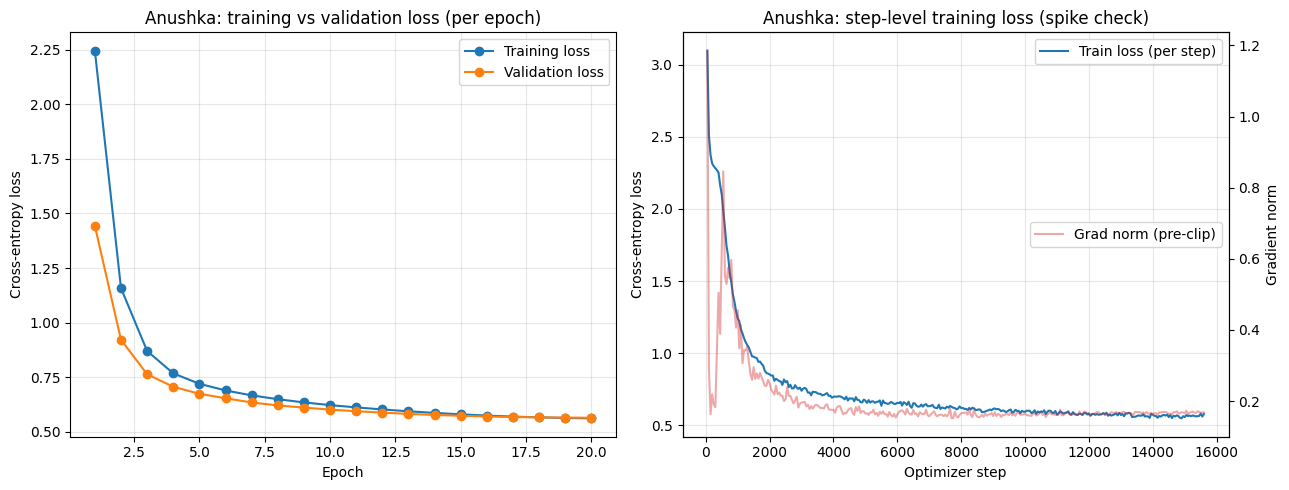

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
epochs_axis = range(1, len(history['train_loss']) + 1)
axes[0].plot(epochs_axis, history['train_loss'], marker='o', label='Training loss')
axes[0].plot(epochs_axis, history['val_loss'], marker='o', label='Validation loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-entropy loss')
axes[0].set_title('Anushka: training vs validation loss (per epoch)')
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(history['step'], history['step_loss'], label='Train loss (per step)')
axes[1].set_xlabel('Optimizer step')
axes[1].set_ylabel('Cross-entropy loss')
axes[1].set_title('Anushka: step-level training loss (spike check)')
axes[1].grid(alpha=0.3)
ax_g = axes[1].twinx()
ax_g.plot(history['step'], history['step_grad_norm'], color='tab:red', alpha=0.4, label='Grad norm (pre-clip)')
ax_g.set_ylabel('Gradient norm')
axes[1].legend(loc='upper right')
ax_g.legend(loc='center right')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'training_loss_curve.png', dpi=160)
plt.show()

In [14]:
# Complete evaluation metrics required by the lab.
import csv

def evaluate_loss_accuracy(model, loader, max_batches=None):
    model.eval()
    total_loss = 0.0
    total_tokens = 0
    correct_tokens = 0

    with torch.no_grad():
        for batch_index, (x, y) in enumerate(loader):
            if max_batches is not None and batch_index >= max_batches:
                break
            x, y = x.to(device), y.to(device)
            logits = model(x)
            flat_logits = logits.reshape(-1, len(chars))
            flat_y = y.reshape(-1)
            total_loss += float(nn.functional.cross_entropy(flat_logits, flat_y, reduction='sum'))
            correct_tokens += int((flat_logits.argmax(dim=-1) == flat_y).sum())
            total_tokens += flat_y.numel()

    loss_value = total_loss / max(1, total_tokens)
    return {
        'cross_entropy_loss': loss_value,
        'perplexity': math.exp(min(loss_value, 20.0)),
        'bits_per_character': loss_value / math.log(2.0),
        'top1_next_character_accuracy': correct_tokens / max(1, total_tokens),
        'tokens_evaluated': total_tokens
    }

def distinct_rate(text, n):
    ngrams = [text[i:i+n] for i in range(max(0, len(text)-n+1))]
    return len(set(ngrams)) / max(1, len(ngrams))

def repeated_ngram_rate(text, n=4):
    ngrams = [text[i:i+n] for i in range(max(0, len(text)-n+1))]
    if not ngrams:
        return 0.0
    return 1.0 - (len(set(ngrams)) / len(ngrams))

eval_limit = None if RUN_FULL_TRAINING else SMOKE_EVAL_BATCHES
train_metrics = evaluate_loss_accuracy(model, train_loader, eval_limit)
val_metrics = evaluate_loss_accuracy(model, val_loader, eval_limit)

generated_texts = {'greedy': sample_text}
# tokens/sec counts only newly generated characters (not the prompt)
generation_speeds = {'greedy': CONFIG['max_generation_tokens'] / max(generation_seconds, 1e-9)}
for temperature in [0.5, 1.0, 1.5]:
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    start = time.time()
    generated = generate_text(
        model,
        prompt='Once upon a time, ',
        max_new_tokens=CONFIG['max_generation_tokens'],
        temperature=temperature,
        sample=True
    )
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    seconds = time.time() - start
    generated_texts[f'temperature_{temperature}'] = generated
    generation_speeds[f'temperature_{temperature}'] = CONFIG['max_generation_tokens'] / max(seconds, 1e-9)

(OUTPUT_DIR / 'generated_samples.txt').write_text(
    '\n\n'.join(f'[{name}]\n{text}' for name, text in generated_texts.items()),
    encoding='utf-8'
)

representative_generation = generated_texts['temperature_1.0']
metric_report = {
    'run_id': RUN_ID,
    'checkpoint': f'checkpoints/{best_ckpt_name}',
    'checkpoint_epoch': best_ckpt['epoch'],
    'epochs_trained': len(history['train_loss']),
    'training_cross_entropy_loss': train_metrics['cross_entropy_loss'],
    'validation_cross_entropy_loss': val_metrics['cross_entropy_loss'],
    'training_perplexity': train_metrics['perplexity'],
    'validation_perplexity': val_metrics['perplexity'],
    'training_bits_per_character': train_metrics['bits_per_character'],
    'validation_bits_per_character': val_metrics['bits_per_character'],
    'generalization_gap': val_metrics['cross_entropy_loss'] - train_metrics['cross_entropy_loss'],
    'training_top1_next_character_accuracy': train_metrics['top1_next_character_accuracy'],
    'validation_top1_next_character_accuracy': val_metrics['top1_next_character_accuracy'],
    'distinct_1': distinct_rate(representative_generation, 1),
    'distinct_2': distinct_rate(representative_generation, 2),
    'distinct_3': distinct_rate(representative_generation, 3),
    'repeated_4gram_rate': repeated_ngram_rate(representative_generation, 4),
    'mean_gradient_norm': float(np.mean(history.get('gradient_norm', [float('nan')]))),
    'max_gradient_norm': float(np.max(history.get('max_gradient_norm', [float('nan')]))),
    'nan_count': int(history.get('nan_count', 0)),
    'parameter_count': parameter_count,
    'training_tokens_per_second': float(np.mean(history.get('tokens_per_sec', [float('nan')]))),
    'generation_tokens_per_second_greedy': generation_speeds['greedy'],
    'generation_tokens_per_second_sampled_t1.0': generation_speeds['temperature_1.0'],
    'peak_memory_mb': float(torch.cuda.max_memory_allocated() / (1024**2)) if torch.cuda.is_available() else 0.0,
    'total_training_time_seconds': float(history.get('total_training_time_seconds', float('nan'))),
    'device': str(device),
    'gpu_name': torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU',
    'smoke_test': not RUN_FULL_TRAINING
}

(OUTPUT_DIR / 'metrics.json').write_text(json.dumps(metric_report, indent=2))
with (MEMBER_DIR / 'metrics_report.csv').open('w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['metric', 'value'])
    for key, value in metric_report.items():
        writer.writerow([key, value])

print(json.dumps(metric_report, indent=2))

{
  "run_id": "20260929_225852",
  "checkpoint": "checkpoints/best_model.pt",
  "checkpoint_epoch": 20,
  "epochs_trained": 20,
  "training_cross_entropy_loss": 0.5252033277130127,
  "validation_cross_entropy_loss": 0.5650785626411438,
  "training_perplexity": 1.6908026004566519,
  "validation_perplexity": 1.7595860150164562,
  "training_bits_per_character": 0.7577082363499446,
  "validation_bits_per_character": 0.8152360400350416,
  "generalization_gap": 0.039875234928131054,
  "training_top1_next_character_accuracy": 0.83114931640625,
  "validation_top1_next_character_accuracy": 0.8201212890625,
  "distinct_1": 0.1069182389937107,
  "distinct_2": 0.4889589905362776,
  "distinct_3": 0.7784810126582279,
  "repeated_4gram_rate": 0.10158730158730156,
  "mean_gradient_norm": 0.20062970810324487,
  "max_gradient_norm": 2.2634670734405518,
  "nan_count": 0,
  "parameter_count": 10926443,
  "training_tokens_per_second": 399476.42368789454,
  "generation_tokens_per_second_greedy": 596.6078036

## 1.4 Sequence Model Failure Analysis

After the final GPU-lab run, review the generated samples and document three failures.

For every case, include:
1. The exact generated text snippet.
2. The failure type: repetition, broken grammar, loss of coherence, hallucination, or another justified category.
3. A short explanation of what went wrong.
4. One possible improvement.


In [15]:
# Create editable templates for the required written analysis.
# Only created if missing, so re-running the notebook never overwrites what you wrote.
failure_template = '''# Sequence Model Failure Analysis

## Failure Case 1
Generated snippet:

Failure type:

Observation:

Possible improvement:

## Failure Case 2
Generated snippet:

Failure type:

Observation:

Possible improvement:

## Failure Case 3
Generated snippet:

Failure type:

Observation:

Possible improvement:
'''

results_template = '''# Task 1 Results (Anushka)

## Architecture
Describe the manual character-level GPT architecture and explain the main choices.

## Hyperparameters
Report the values from src/config.json.

## Results
Summarize the values in metrics_report.csv and include outputs/training_loss_curve.png.

## Failure Analysis
Summarize the three cases in failure_analysis.md.

## Hardware
Record the exact GPU or CPU, peak memory, and total training time.
'''

for path, text in [(MEMBER_DIR / 'failure_analysis.md', failure_template),
                   (MEMBER_DIR / 'results.md', results_template)]:
    if not path.exists() or path.stat().st_size == 0:
        path.write_text(text, encoding='utf-8')
        print('Created', path.relative_to(REPO_ROOT))
    else:
        print('Kept existing', path.relative_to(REPO_ROOT))

# Reproducibility manifest: environment + which checkpoint produced which numbers.
import platform, subprocess, sys
pip_freeze = subprocess.run([sys.executable, '-m', 'pip', 'freeze'], capture_output=True, text=True).stdout
manifest = {
    'member': MEMBER_NAME,
    'task': 'task1_llm',
    'run_id': RUN_ID,
    'python': sys.version,
    'platform': platform.platform(),
    'torch': torch.__version__,
    'cuda': torch.version.cuda,
    'gpu': torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU',
    'config_file': 'task1_llm/member_anushka/src/config.json',
    'raw_log': str((LOG_DIR / f"{'full' if RUN_FULL_TRAINING else 'smoke'}_training_log_{RUN_ID}.txt").relative_to(REPO_ROOT)),
    'checkpoint_to_results': {
        f'task1_llm/member_anushka/checkpoints/{best_ckpt_name}': 'task1_llm/member_anushka/metrics_report.csv',
    },
}
(MANIFEST_DIR / f'task1_llm_{MEMBER_NAME}_manifest.json').write_text(json.dumps(manifest, indent=2))
(MANIFEST_DIR / f'task1_llm_{MEMBER_NAME}_requirements.txt').write_text(pip_freeze)
print('Wrote manifest + requirements to', MANIFEST_DIR.relative_to(REPO_ROOT))

Kept existing task1_llm/member_anushka/failure_analysis.md
Kept existing task1_llm/member_anushka/results.md
Wrote manifest + requirements to reproducibility/manifests


## Final Output Checklist

Before submission, confirm these exist (paths relative to the repo root):

- task1_llm/member_anushka/src/Part1_LLM.ipynb (executed, outputs visible)
- task1_llm/member_anushka/src/config.json
- task1_llm/member_anushka/data_processed/character_vocabulary.json
- task1_llm/member_anushka/checkpoints/best_model.pt and last_model.pt (Git LFS)
- task1_llm/member_anushka/outputs/training_loss_curve.png
- task1_llm/member_anushka/outputs/generated_samples.txt
- task1_llm/member_anushka/outputs/metrics.json
- task1_llm/member_anushka/metrics_report.csv
- task1_llm/member_anushka/failure_analysis.md
- task1_llm/member_anushka/results.md
- reproducibility/raw_logs/task1_llm_anushka/full_training_log_<RUN_ID>.txt
- reproducibility/manifests/task1_llm_anushka_manifest.json and _requirements.txt